# Import dataset:

In [8]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning)

warnings.filterwarnings(
    "ignore",
    message="The default of observed=False is deprecated",
    category=FutureWarning)

warnings.filterwarnings(
    "ignore",
    message="When grouping with a length-1 list-like",
    category=FutureWarning)

warnings.simplefilter(action='ignore', category=FutureWarning)

train = pd.read_csv('../Data/train.csv', index_col = 'id')
test = pd.read_csv('../Data/test.csv', index_col = 'id')
print('Size of train dataset: ',train.shape)
print('Size of test dataset: ',test.shape)
train

Size of train dataset:  (700000, 25)
Size of test dataset:  (300000, 24)


,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
id,,,,,,,,,,,,,,,,,,,,,
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,29,1,59,6.9,5.2,1.5,26.1,0.88,133,57,...,Female,Hispanic,Postgraduate,Upper-Middle,Former,Employed,0,0,0,0.0
699996,46,2,72,7.7,7.7,3.8,25.5,0.85,106,85,...,Female,Hispanic,Graduate,Upper-Middle,Former,Employed,0,0,1,1.0
699997,35,1,50,5.6,6.1,6.4,26.9,0.88,127,84,...,Female,White,Graduate,Middle,Never,Employed,0,0,0,1.0


In [2]:
print('Missing values of train:',int(train.isnull().sum().sum()))
print('Missing values of test:',int(test.isnull().sum().sum()))

Missing values of train: 0
Missing values of test: 0


In [3]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
age,700000.0,50.359734,11.655520,19.00,42.00,50.00,58.00,89.00
alcohol_consumption_per_week,700000.0,2.072411,1.048189,1.00,1.00,2.00,3.00,9.00
physical_activity_minutes_per_week,700000.0,80.230803,51.195071,1.00,49.00,71.00,96.00,747.00
diet_score,700000.0,5.963695,1.463336,0.10,5.00,6.00,7.00,9.90
sleep_hours_per_day,700000.0,7.002200,0.901907,3.10,6.40,7.00,7.60,9.90
screen_time_hours_per_day,700000.0,6.012733,2.022707,0.60,4.60,6.00,7.40,16.50
bmi,700000.0,25.874684,2.860705,15.10,23.90,25.90,27.80,38.40
waist_to_hip_ratio,700000.0,0.858766,0.037980,0.68,0.83,0.86,0.88,1.05
systolic_bp,700000.0,116.294193,11.010390,91.00,108.00,116.00,124.00,163.00
diastolic_bp,700000.0,75.440924,6.825775,51.00,71.00,75.00,80.00,104.00


# Check data distribution between Train vs Test:

In [4]:
def overview(df, nunique_threshold=15):
    """
    Prints an overview of the DataFrame.
    - Ignores the last column (assumed target).
    - Counts numerical and categorical features.
    - Converts low-cardinality numeric features to categorical.
    """

    import pandas as pd

    # Drop last column (assumed target)
    features = df.iloc[:, :-1]

    # Initial type detection
    num_cols = features.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = features.select_dtypes(include=['object', 'category']).columns.tolist()

    # Convert low-cardinality numeric columns to categorical
    converted_cols = []
    for col in num_cols.copy():
        if features[col].nunique() <= nunique_threshold:
            df[col] = df[col].astype('category')
            num_cols.remove(col)
            cat_cols.append(col)
            converted_cols.append(col)

    print("===== DATA OVERVIEW =====")
    print(f"Total features (excluding last column): {features.shape[1]}")
    print(f"Numeric features: {len(num_cols)}")
    print(f"Categorical features: {len(cat_cols)}")

    if converted_cols:
        print(f"\nConverted to categorical (nunique ≤ {nunique_threshold}):")
        for col in converted_cols:
            print(f"  - {col}")

    print("\n--- Categorical Columns Detail ---")
    for col in cat_cols:
        print(f"{col}: {df[col].nunique()} unique values")

    return num_cols, cat_cols

num_cols, cat_cols = overview(train)

===== DATA OVERVIEW =====
Total features (excluding last column): 24
Numeric features: 14
Categorical features: 10

Converted to categorical (nunique ≤ 15):
  - alcohol_consumption_per_week
  - family_history_diabetes
  - hypertension_history
  - cardiovascular_history

--- Categorical Columns Detail ---
gender: 3 unique values
ethnicity: 5 unique values
education_level: 4 unique values
income_level: 5 unique values
smoking_status: 3 unique values
employment_status: 4 unique values
alcohol_consumption_per_week: 9 unique values
family_history_diabetes: 2 unique values
hypertension_history: 2 unique values
cardiovascular_history: 2 unique values


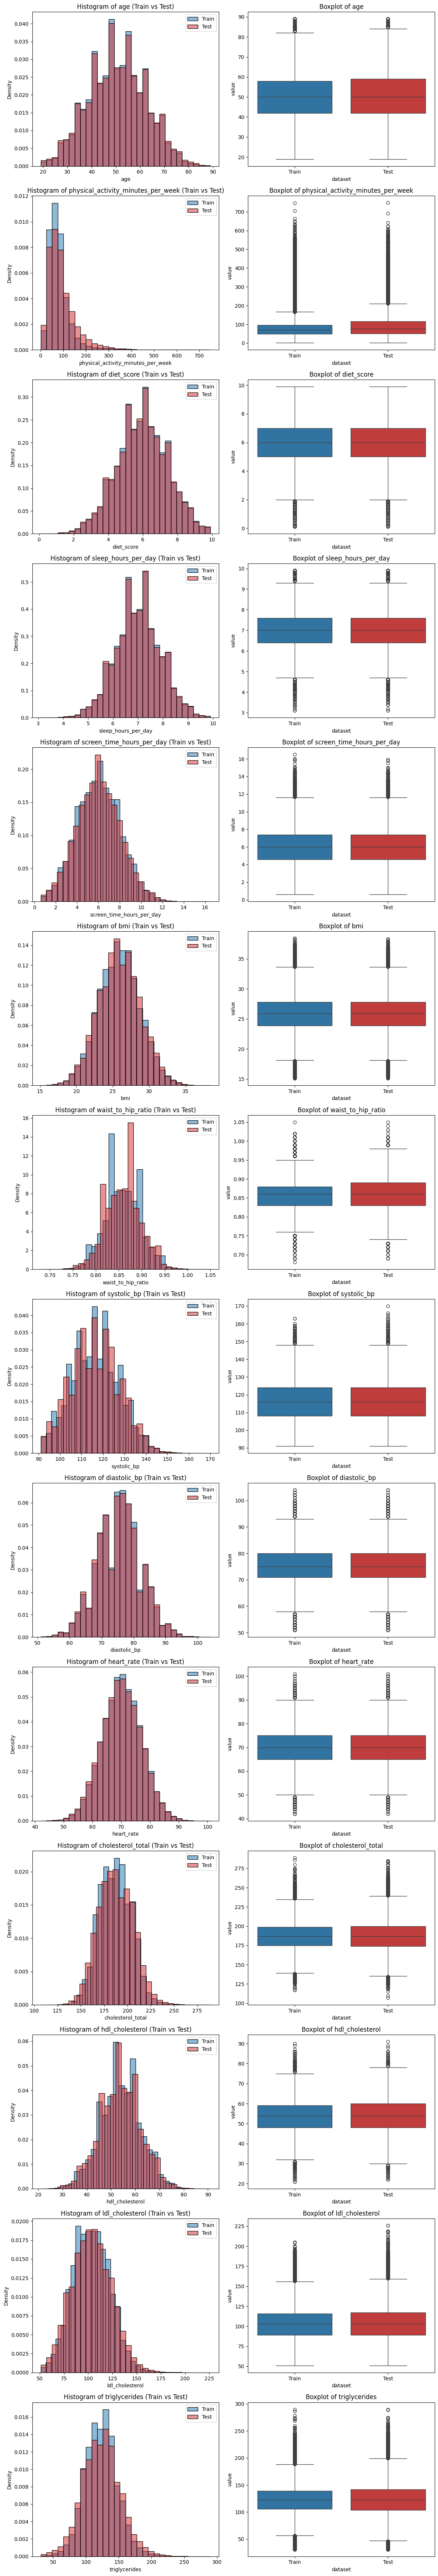

In [5]:
def compare_numeric_distribution(train_df, test_df, num_cols, bins=30):
    """
    Compare numerical feature distributions between train and test datasets.

    Parameters:
        train_df (pd.DataFrame): Training dataset
        test_df (pd.DataFrame): Testing dataset
        num_cols (list): List of numerical column names to compare
        bins (int): Histogram bin count
    """
    n = len(num_cols)
    fig, axes = plt.subplots(n, 2, figsize=(12, 5 * n))

    if n == 1:
        axes = [axes]

    # Consistent color mapping
    palette = {
        "Train": "#1f77b4",  # blue
        "Test": "#d62728"    # red
    }

    for idx, col in enumerate(num_cols):
        ax_hist, ax_box = axes[idx]

        # --- Histogram overlay ---
        sns.histplot(
            train_df[col],
            bins=bins,
            stat="density",
            alpha=0.5,
            color=palette["Train"],
            label="Train",
            ax=ax_hist
        )
        sns.histplot(
            test_df[col],
            bins=bins,
            stat="density",
            alpha=0.5,
            color=palette["Test"],
            label="Test",
            ax=ax_hist
        )

        ax_hist.set_title(f"Histogram of {col} (Train vs Test)")
        ax_hist.legend()

        # --- Boxplot with different colors ---
        box_data = pd.DataFrame({
            "value": pd.concat([train_df[col], test_df[col]]),
            "dataset": (["Train"] * len(train_df[col])) +
                       (["Test"] * len(test_df[col]))
        })

        sns.boxplot(
            x="dataset",
            y="value",
            data=box_data,
            palette=palette,
            ax=ax_box
        )

        ax_box.set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

compare_numeric_distribution(train, test, num_cols, bins=30)

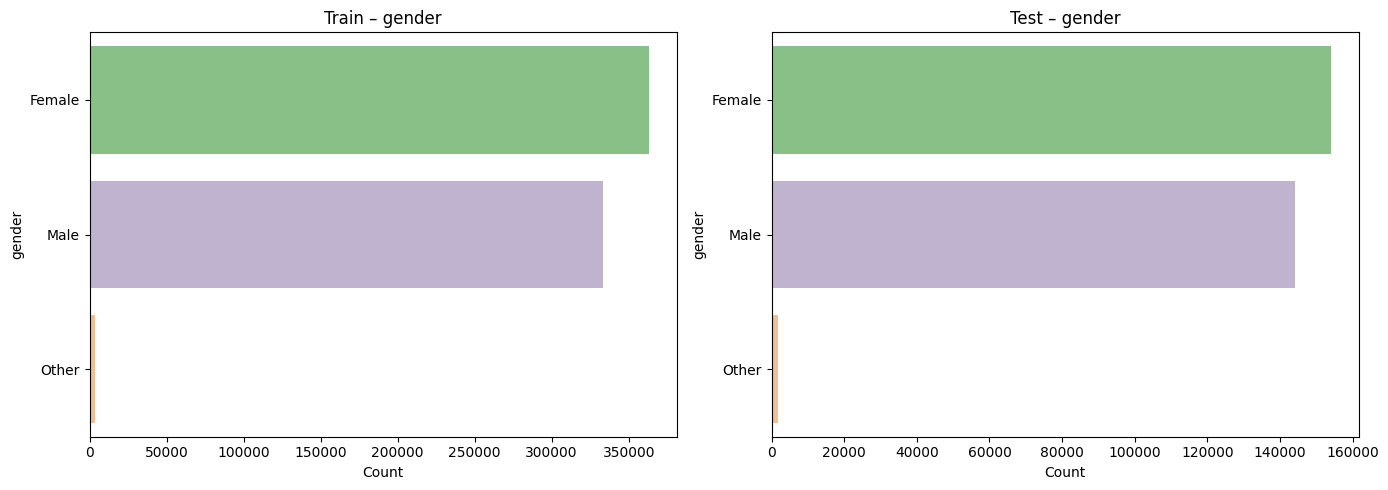

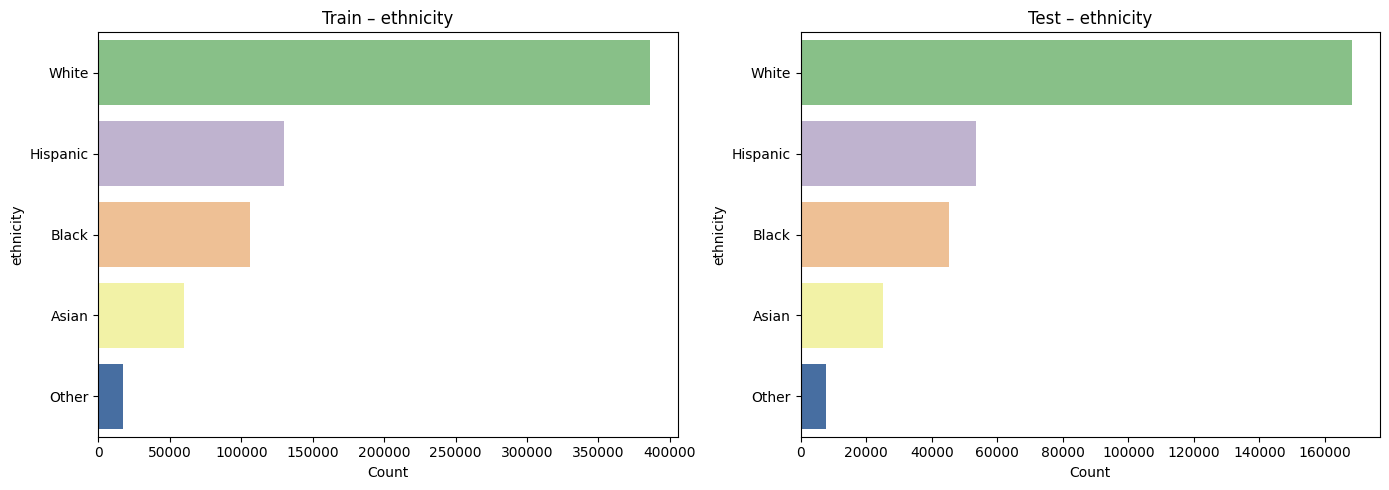

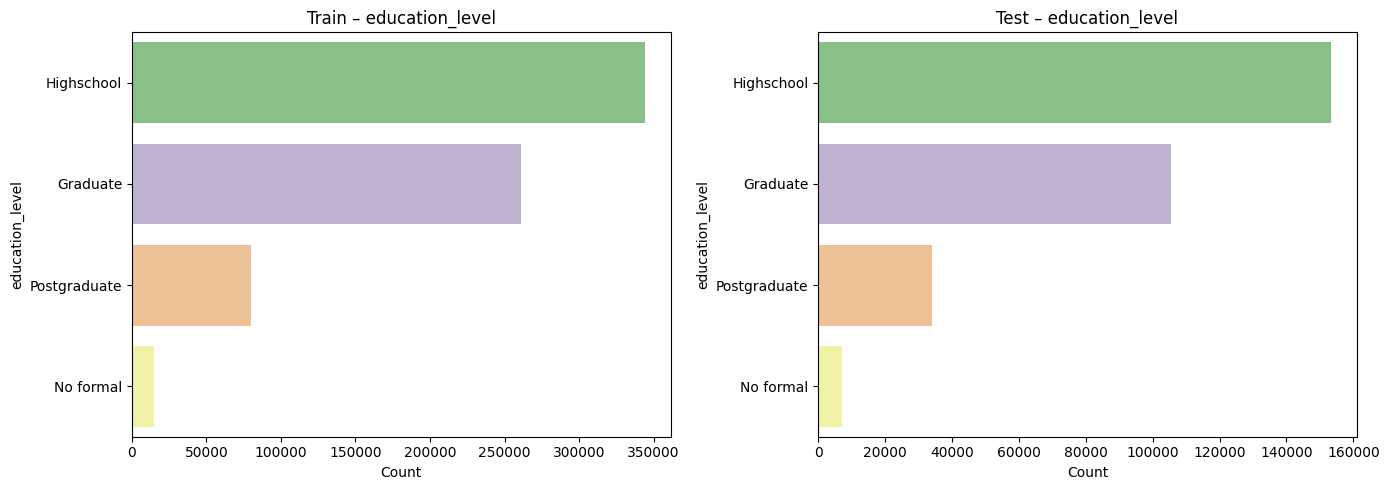

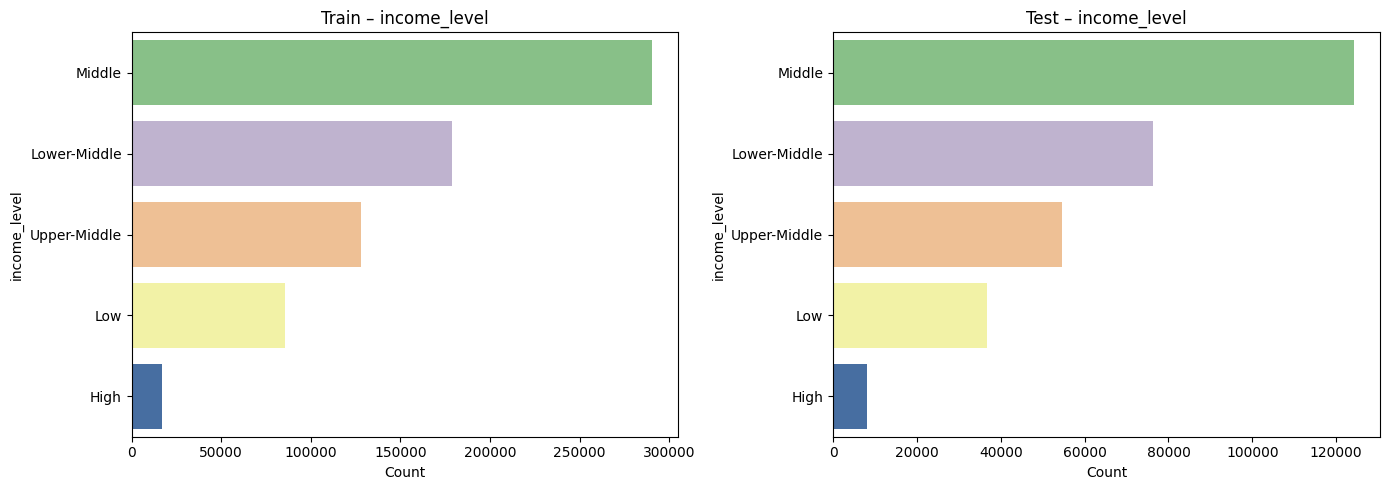

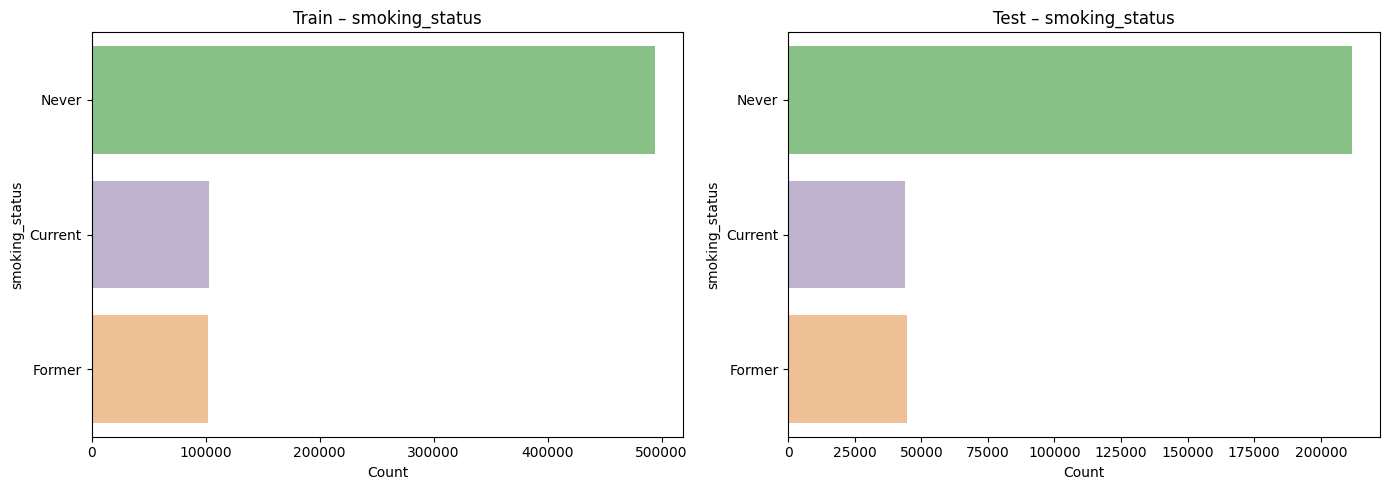

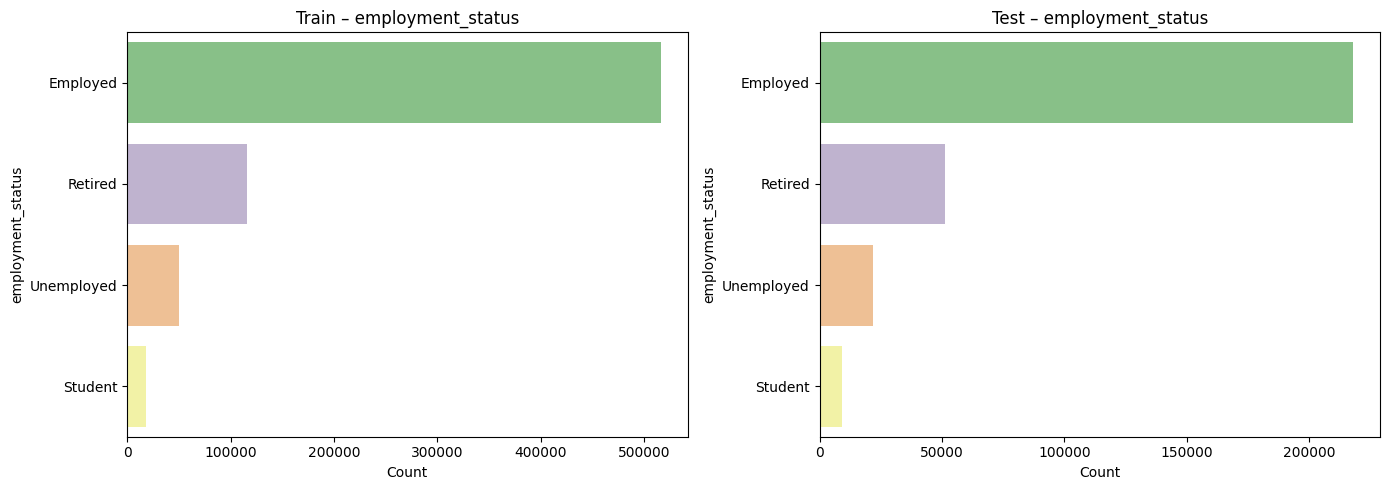

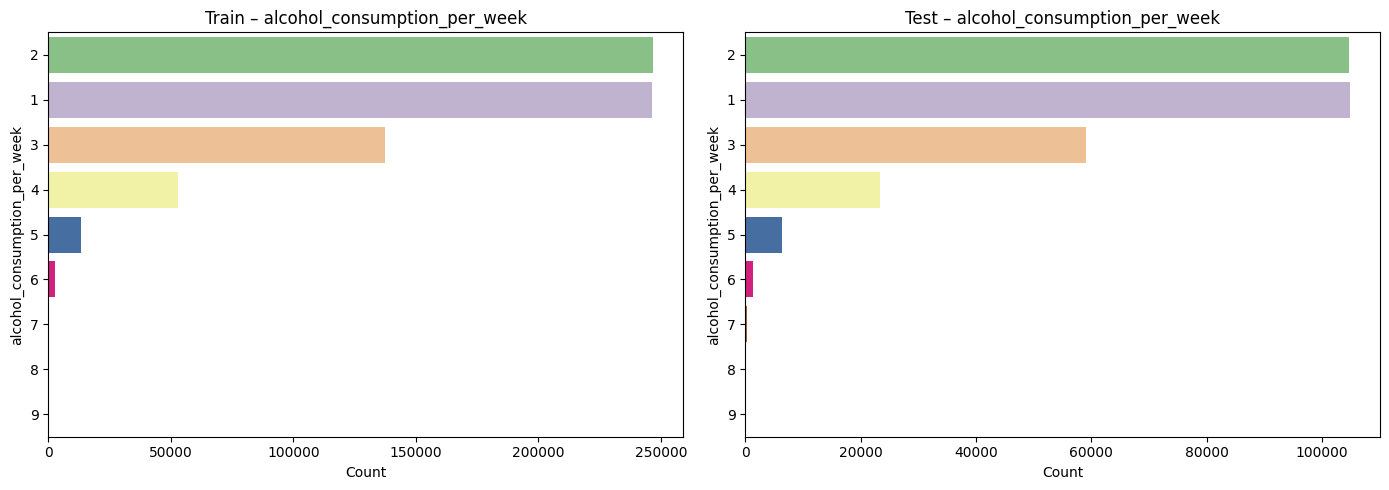

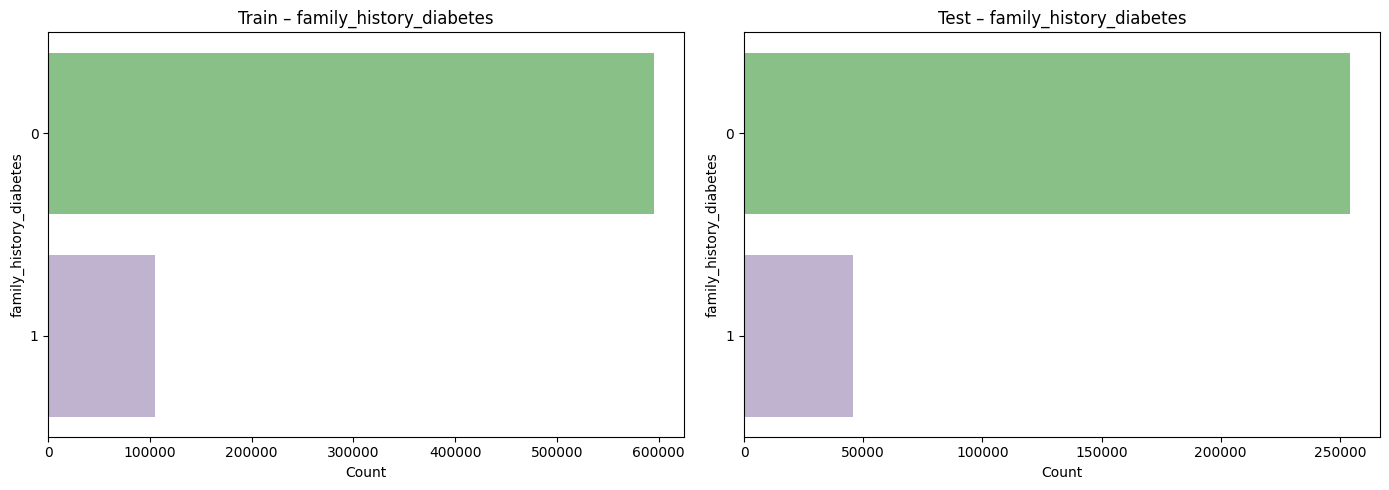

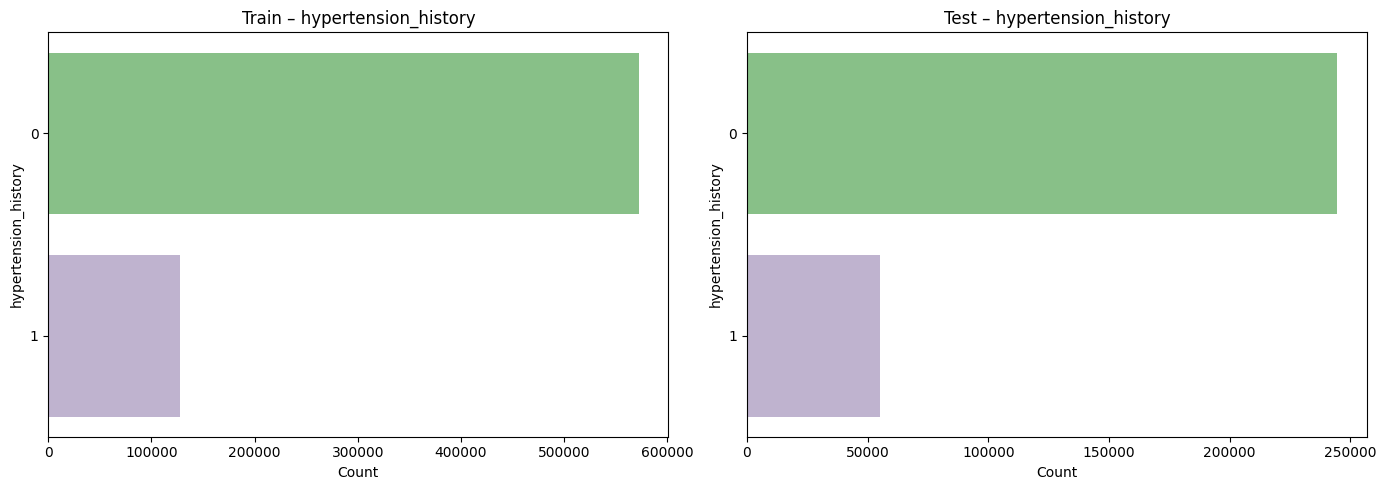

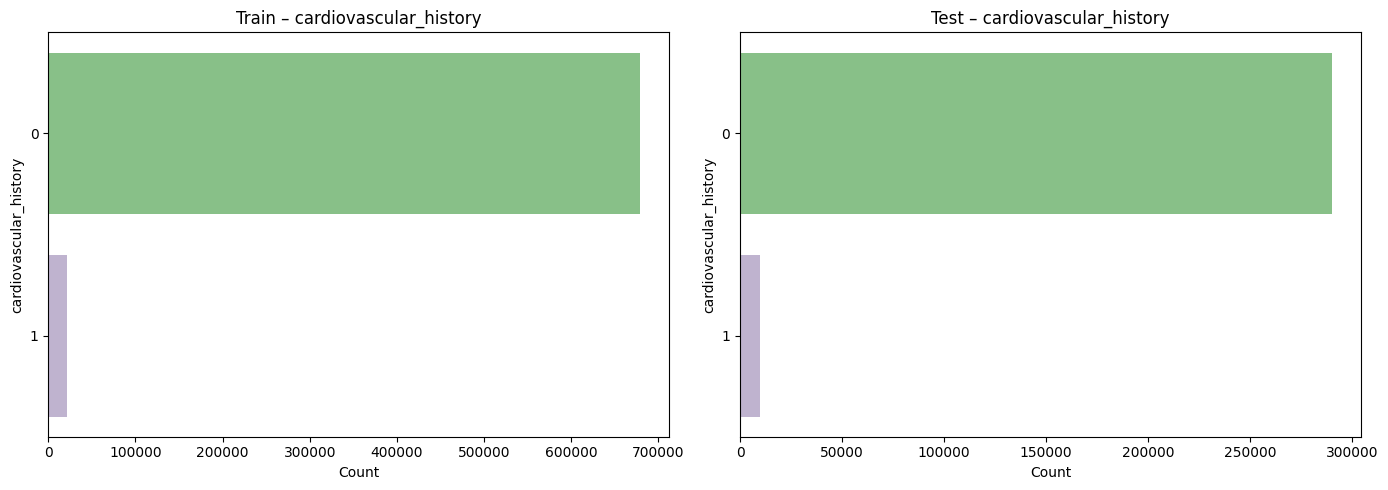

In [6]:
def compare_categorical_distribution(train_df, test_df, cat_cols):
    """
    Compare categorical feature distributions between train and test datasets.

    - Builds a unified category order (train frequency first, then test-only).
    - Enforces identical ordering for train and test.
    - Applies a single, consistent color per category across both plots.
    - Safely handles numeric categorical variables by coercing to string
      (required for seaborn palette mapping).
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    for col in cat_cols:
        # --- Force string representation (critical for seaborn palette mapping) ---
        train_vals = train_df[col].astype(str)
        test_vals = test_df[col].astype(str)

        # --- Order categories by train frequency ---
        train_order = train_vals.value_counts().index.tolist()

        # --- Add categories seen only in test ---
        test_unique = pd.Index(test_vals.dropna().unique())
        test_only = test_unique.difference(train_order).tolist()

        full_order = train_order + test_only

        # --- One color per category (shared across plots) ---
        palette = dict(
            zip(full_order, sns.color_palette("Accent", n_colors=len(full_order)))
        )

        # --- Plot ---
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        sns.countplot(
            y=train_vals,
            order=full_order,
            palette=palette,
            ax=axes[0]
        )
        axes[0].set_title(f"Train – {col}")
        axes[0].set_xlabel("Count")

        sns.countplot(
            y=test_vals,
            order=full_order,
            palette=palette,
            ax=axes[1]
        )
        axes[1].set_title(f"Test – {col}")
        axes[1].set_xlabel("Count")

        plt.tight_layout()
        plt.show()


compare_categorical_distribution(train, test, cat_cols)